# Chapter 6: Production Well Networks and Artificial Lift

**Production Optimization of Oil and Gas Fields Using NeqSim**

This notebook demonstrates well network modeling including:
- Single well with tubing, choke valve, and flowline
- Multi-well gathering network (3 wells to manifold)
- Choke sensitivity study varying opening from 10% to 100%
- Wellhead pressure vs flow rate analysis

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch15w_well_networks.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


## 1. Single Well Model: Tubing + Choke + Flowline

We model a single production well with:
- A reservoir fluid (oil with associated gas)
- Vertical tubing (2000 m depth, 4-inch ID)
- Wellhead choke valve (Cv-based)
- Horizontal flowline to the production manifold (5 km)

In [2]:
# jneqsim is bound to the source JVM in the setup cell.

# Create reservoir fluid - oil with dissolved gas
fluid = jneqsim.thermo.system.SystemSrkEos(273.15 + 80.0, 250.0)
fluid.addComponent("nitrogen", 0.5)
fluid.addComponent("CO2", 1.5)
fluid.addComponent("methane", 45.0)
fluid.addComponent("ethane", 8.0)
fluid.addComponent("propane", 5.0)
fluid.addComponent("i-butane", 1.5)
fluid.addComponent("n-butane", 2.5)
fluid.addComponent("i-pentane", 1.5)
fluid.addComponent("n-pentane", 1.5)
fluid.addComponent("n-hexane", 3.0)
fluid.addComponent("n-heptane", 10.0)
fluid.addComponent("n-octane", 8.0)
fluid.addComponent("water", 12.0)
fluid.setMixingRule("classic")
fluid.setMultiPhaseCheck(True)

# --- Well stream ---
well_stream = jneqsim.process.equipment.stream.Stream("Well Stream", fluid)
well_stream.setFlowRate(50000.0, "kg/hr")
well_stream.setTemperature(80.0, "C")
well_stream.setPressure(250.0, "bara")

# --- Tubing (vertical, 2000 m) ---
tubing = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills("Tubing", well_stream)
tubing.setLength(2000.0)
tubing.setElevation(2000.0)  # positive elevation means upward flow
tubing.setDiameter(0.1016)  # 4 inch
tubing.setPipeWallRoughness(4.5e-5)
tubing.setNumberOfIncrements(20)

# --- Wellhead choke ---
choke = jneqsim.process.equipment.valve.ThrottlingValve("Choke", tubing.getOutletStream())
choke.setCv(30.0)
choke.setIsCalcOutPressure(True)
choke.setPercentValveOpening(50.0)

# --- Flowline to manifold (horizontal, 5 km) ---
flowline = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills("Flowline", choke.getOutletStream())
flowline.setLength(5000.0)
flowline.setElevation(0.0)
flowline.setDiameter(0.2032)  # 8 inch
flowline.setPipeWallRoughness(4.5e-5)
flowline.setNumberOfIncrements(20)

# Build and run process
process = jneqsim.process.processmodel.ProcessSystem()
process.add(well_stream)
process.add(tubing)
process.add(choke)
process.add(flowline)
process.run()

print("=== Single Well Model Results ===")
print(f"Wellhead pressure (after tubing): {tubing.getOutletStream().getPressure('bara'):.1f} bara")
print(f"Choke outlet pressure:            {choke.getOutletStream().getPressure('bara'):.1f} bara")
print(f"Manifold arrival pressure:        {flowline.getOutletStream().getPressure('bara'):.1f} bara")
print(f"Manifold arrival temperature:     {flowline.getOutletStream().getTemperature('C'):.1f} C")
print(f"Tubing pressure drop:             {tubing.getPressureDrop():.1f} bar")
print(f"Flowline pressure drop:           {flowline.getPressureDrop():.1f} bar")

=== Single Well Model Results ===
Wellhead pressure (after tubing): 151.0 bara
Choke outlet pressure:            113.1 bara
Manifold arrival pressure:        111.5 bara
Manifold arrival temperature:     77.5 C
Tubing pressure drop:             99.0 bar
Flowline pressure drop:           1.6 bar


## 2. Choke Sensitivity Study

We vary the choke opening from 10% to 100% to study the effect on flow rate
and downstream pressure. This is a key optimization variable for well
production management.

In [3]:
# Choke sensitivity: vary opening from 10% to 100%
choke_openings = np.arange(10, 101, 10)
choke_outlet_pressures = []
manifold_pressures = []
flow_rates_kg_hr = []

for opening in choke_openings:
    choke.setPercentValveOpening(float(opening))
    try:
        process.run()
    except Exception as error:
        print(f"Opening {opening:.0f}% cannot pass the imposed 50 t/hr through the choke and flowline: {error}")
        choke_outlet_pressures.append(np.nan)
        manifold_pressures.append(np.nan)
        flow_rates_kg_hr.append(np.nan)
        continue

    p_choke_out = choke.getOutletStream().getPressure("bara")
    p_manifold = flowline.getOutletStream().getPressure("bara")
    assert 0 < p_choke_out <= tubing.getOutletStream().getPressure("bara"), "Passive choke cannot increase pressure"
    flow = well_stream.getFlowRate("kg/hr")

    choke_outlet_pressures.append(p_choke_out)
    manifold_pressures.append(p_manifold)
    flow_rates_kg_hr.append(flow)

print("Choke Opening (%) | Choke P_out (bara) | Manifold P (bara)")
print("-" * 58)
for i, op in enumerate(choke_openings):
    print(f"{op:>17.0f} | {choke_outlet_pressures[i]:>18.1f} | {manifold_pressures[i]:>17.1f}")

Opening 10% cannot pass the imposed 50 t/hr through the choke and flowline: java.lang.RuntimeException: Failed to run unit operation Flowline
Opening 20% cannot pass the imposed 50 t/hr through the choke and flowline: java.lang.RuntimeException: Failed to run unit operation Flowline
Choke Opening (%) | Choke P_out (bara) | Manifold P (bara)
----------------------------------------------------------
               10 |                nan |               nan
               20 |                nan |               nan
               30 |               45.6 |              41.4
               40 |               91.7 |              89.8
               50 |              113.1 |             111.5
               60 |              124.7 |             123.2
               70 |              131.7 |             130.3
               80 |              136.2 |             134.9
               90 |              139.3 |             138.0
              100 |              141.6 |             140.3


Figure saved to ../figures/ch15w_choke_sensitivity.png


ch15w_well_networks.ipynb:cell6:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


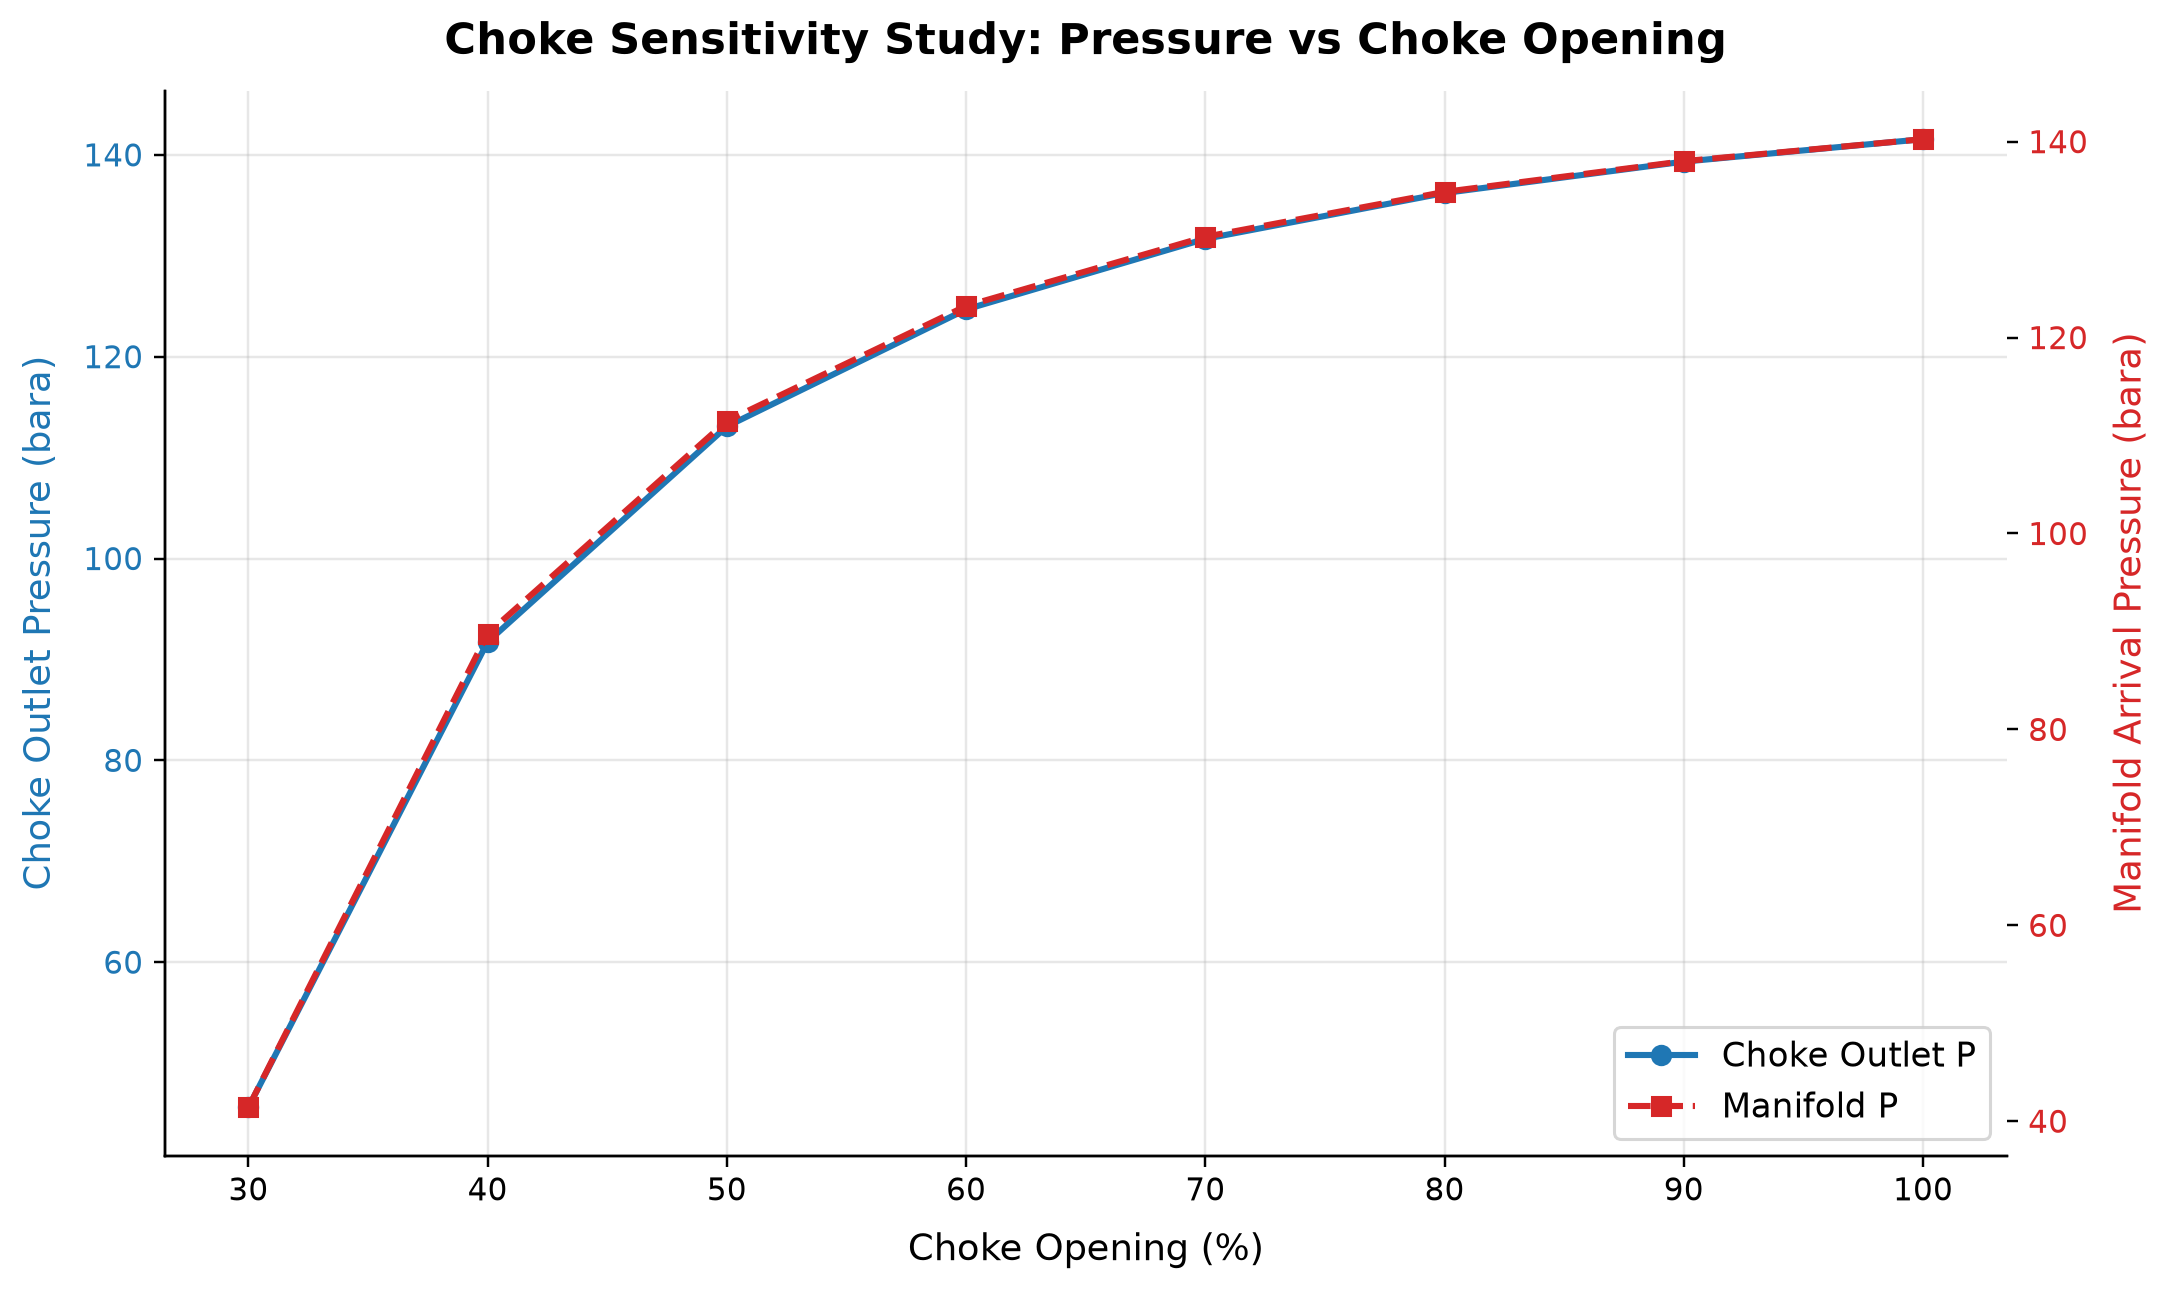

In [4]:
# Plot: Choke outlet pressure vs choke opening
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = "tab:blue"
ax1.set_xlabel("Choke Opening (%)", fontsize=12)
ax1.set_ylabel("Choke Outlet Pressure (bara)", fontsize=12, color=color1)
ax1.plot(choke_openings, choke_outlet_pressures, 'o-', color=color1, linewidth=2, label="Choke Outlet P")
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

color2 = "tab:red"
ax2 = ax1.twinx()
ax2.set_ylabel("Manifold Arrival Pressure (bara)", fontsize=12, color=color2)
ax2.plot(choke_openings, manifold_pressures, 's--', color=color2, linewidth=2, label="Manifold P")
ax2.tick_params(axis='y', labelcolor=color2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right", fontsize=11)

plt.title("Choke Sensitivity Study: Pressure vs Choke Opening", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch15w_choke_sensitivity.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved to ../figures/ch15w_choke_sensitivity.png")

**Executed-figure discussion.** Choke Outlet P: choke outlet pressure spans 45.61–141.6 bara across the plotted cases. Manifold P: manifold arrival pressure spans 41.41–140.3 bara across the plotted cases. Gaps retain undefined phase quantities or hydraulic states that fail the stated operating boundary; they are not interpolated.

At imposed upstream flow, closing a fixed-Cv choke requires more pressure drop; sufficiently restricted openings may have no feasible positive outlet pressure. This pressure-mode experiment is not a prediction that the same well rate remains deliverable at every opening. Reject infeasible pressure solutions and use the coupled reservoir–tubing–network model when translating a choke opening into a production rate.


## 3. Multi-Well Gathering Network

We model three production wells feeding into a common manifold via a mixer.
Each well has different reservoir conditions and flow rates, representing
a typical gathering network scenario.

In [5]:
# --- Well 1: High pressure, low GOR ---
fluid1 = jneqsim.thermo.system.SystemSrkEos(273.15 + 85.0, 280.0)
fluid1.addComponent("methane", 35.0)
fluid1.addComponent("ethane", 5.0)
fluid1.addComponent("propane", 4.0)
fluid1.addComponent("n-butane", 3.0)
fluid1.addComponent("n-hexane", 8.0)
fluid1.addComponent("n-heptane", 15.0)
fluid1.addComponent("n-octane", 12.0)
fluid1.addComponent("water", 18.0)
fluid1.setMixingRule("classic")
fluid1.setMultiPhaseCheck(True)

stream1 = jneqsim.process.equipment.stream.Stream("Well-1", fluid1)
stream1.setFlowRate(40000.0, "kg/hr")
stream1.setTemperature(85.0, "C")
stream1.setPressure(280.0, "bara")

pipe1 = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills("Flowline-1", stream1)
pipe1.setLength(3000.0)
pipe1.setElevation(0.0)
pipe1.setDiameter(0.1524)  # 6 inch
pipe1.setPipeWallRoughness(4.5e-5)
pipe1.setNumberOfIncrements(10)

# --- Well 2: Medium pressure, medium GOR ---
fluid2 = jneqsim.thermo.system.SystemSrkEos(273.15 + 75.0, 220.0)
fluid2.addComponent("methane", 50.0)
fluid2.addComponent("ethane", 8.0)
fluid2.addComponent("propane", 5.0)
fluid2.addComponent("n-butane", 2.0)
fluid2.addComponent("n-hexane", 4.0)
fluid2.addComponent("n-heptane", 10.0)
fluid2.addComponent("n-octane", 6.0)
fluid2.addComponent("water", 15.0)
fluid2.setMixingRule("classic")
fluid2.setMultiPhaseCheck(True)

stream2 = jneqsim.process.equipment.stream.Stream("Well-2", fluid2)
stream2.setFlowRate(35000.0, "kg/hr")
stream2.setTemperature(75.0, "C")
stream2.setPressure(220.0, "bara")

pipe2 = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills("Flowline-2", stream2)
pipe2.setLength(4500.0)
pipe2.setElevation(0.0)
pipe2.setDiameter(0.1524)
pipe2.setPipeWallRoughness(4.5e-5)
pipe2.setNumberOfIncrements(10)

# --- Well 3: Lower pressure, high GOR ---
fluid3 = jneqsim.thermo.system.SystemSrkEos(273.15 + 70.0, 180.0)
fluid3.addComponent("methane", 60.0)
fluid3.addComponent("ethane", 10.0)
fluid3.addComponent("propane", 6.0)
fluid3.addComponent("n-butane", 3.0)
fluid3.addComponent("n-hexane", 3.0)
fluid3.addComponent("n-heptane", 5.0)
fluid3.addComponent("n-octane", 3.0)
fluid3.addComponent("water", 10.0)
fluid3.setMixingRule("classic")
fluid3.setMultiPhaseCheck(True)

stream3 = jneqsim.process.equipment.stream.Stream("Well-3", fluid3)
stream3.setFlowRate(25000.0, "kg/hr")
stream3.setTemperature(70.0, "C")
stream3.setPressure(180.0, "bara")

pipe3 = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills("Flowline-3", stream3)
pipe3.setLength(6000.0)
pipe3.setElevation(0.0)
pipe3.setDiameter(0.1524)
pipe3.setPipeWallRoughness(4.5e-5)
pipe3.setNumberOfIncrements(10)

# --- Manifold (mixer) ---
manifold = jneqsim.process.equipment.mixer.Mixer("Manifold")
manifold.addStream(pipe1.getOutletStream())
manifold.addStream(pipe2.getOutletStream())
manifold.addStream(pipe3.getOutletStream())

# Build process
network = jneqsim.process.processmodel.ProcessSystem()
network.add(stream1)
network.add(pipe1)
network.add(stream2)
network.add(pipe2)
network.add(stream3)
network.add(pipe3)
network.add(manifold)
network.run()

print("=== Multi-Well Gathering Network Results ===")
print(f"{'Well':<12} {'Inlet P (bara)':<16} {'Arrival P (bara)':<18} {'dP (bar)':<12} {'Flow (kg/hr)'}")
print("-" * 72)
for name, s, p in [("Well-1", stream1, pipe1), ("Well-2", stream2, pipe2), ("Well-3", stream3, pipe3)]:
    pin = s.getPressure("bara")
    pout = p.getOutletStream().getPressure("bara")
    dp = p.getPressureDrop()
    flow = s.getFlowRate("kg/hr")
    print(f"{name:<12} {pin:<16.1f} {pout:<18.1f} {dp:<12.1f} {flow:.0f}")

print(f"\nManifold mixed pressure:     {manifold.getOutletStream().getPressure('bara'):.1f} bara")
print(f"Manifold mixed temperature:  {manifold.getOutletStream().getTemperature('C'):.1f} C")
print(f"Total manifold flow:         {manifold.getOutletStream().getFlowRate('kg/hr'):.0f} kg/hr")

=== Multi-Well Gathering Network Results ===
Well         Inlet P (bara)   Arrival P (bara)   dP (bar)     Flow (kg/hr)
------------------------------------------------------------------------
Well-1       280.0            279.0              1.0          40000
Well-2       220.0            218.5              1.5          35000
Well-3       180.0            177.9              2.1          25000

Manifold mixed pressure:     177.9 bara
Manifold mixed temperature:  78.6 C
Total manifold flow:         100000 kg/hr


Figure saved to ../figures/ch15w_well_network_comparison.png


ch15w_well_networks.ipynb:cell9:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


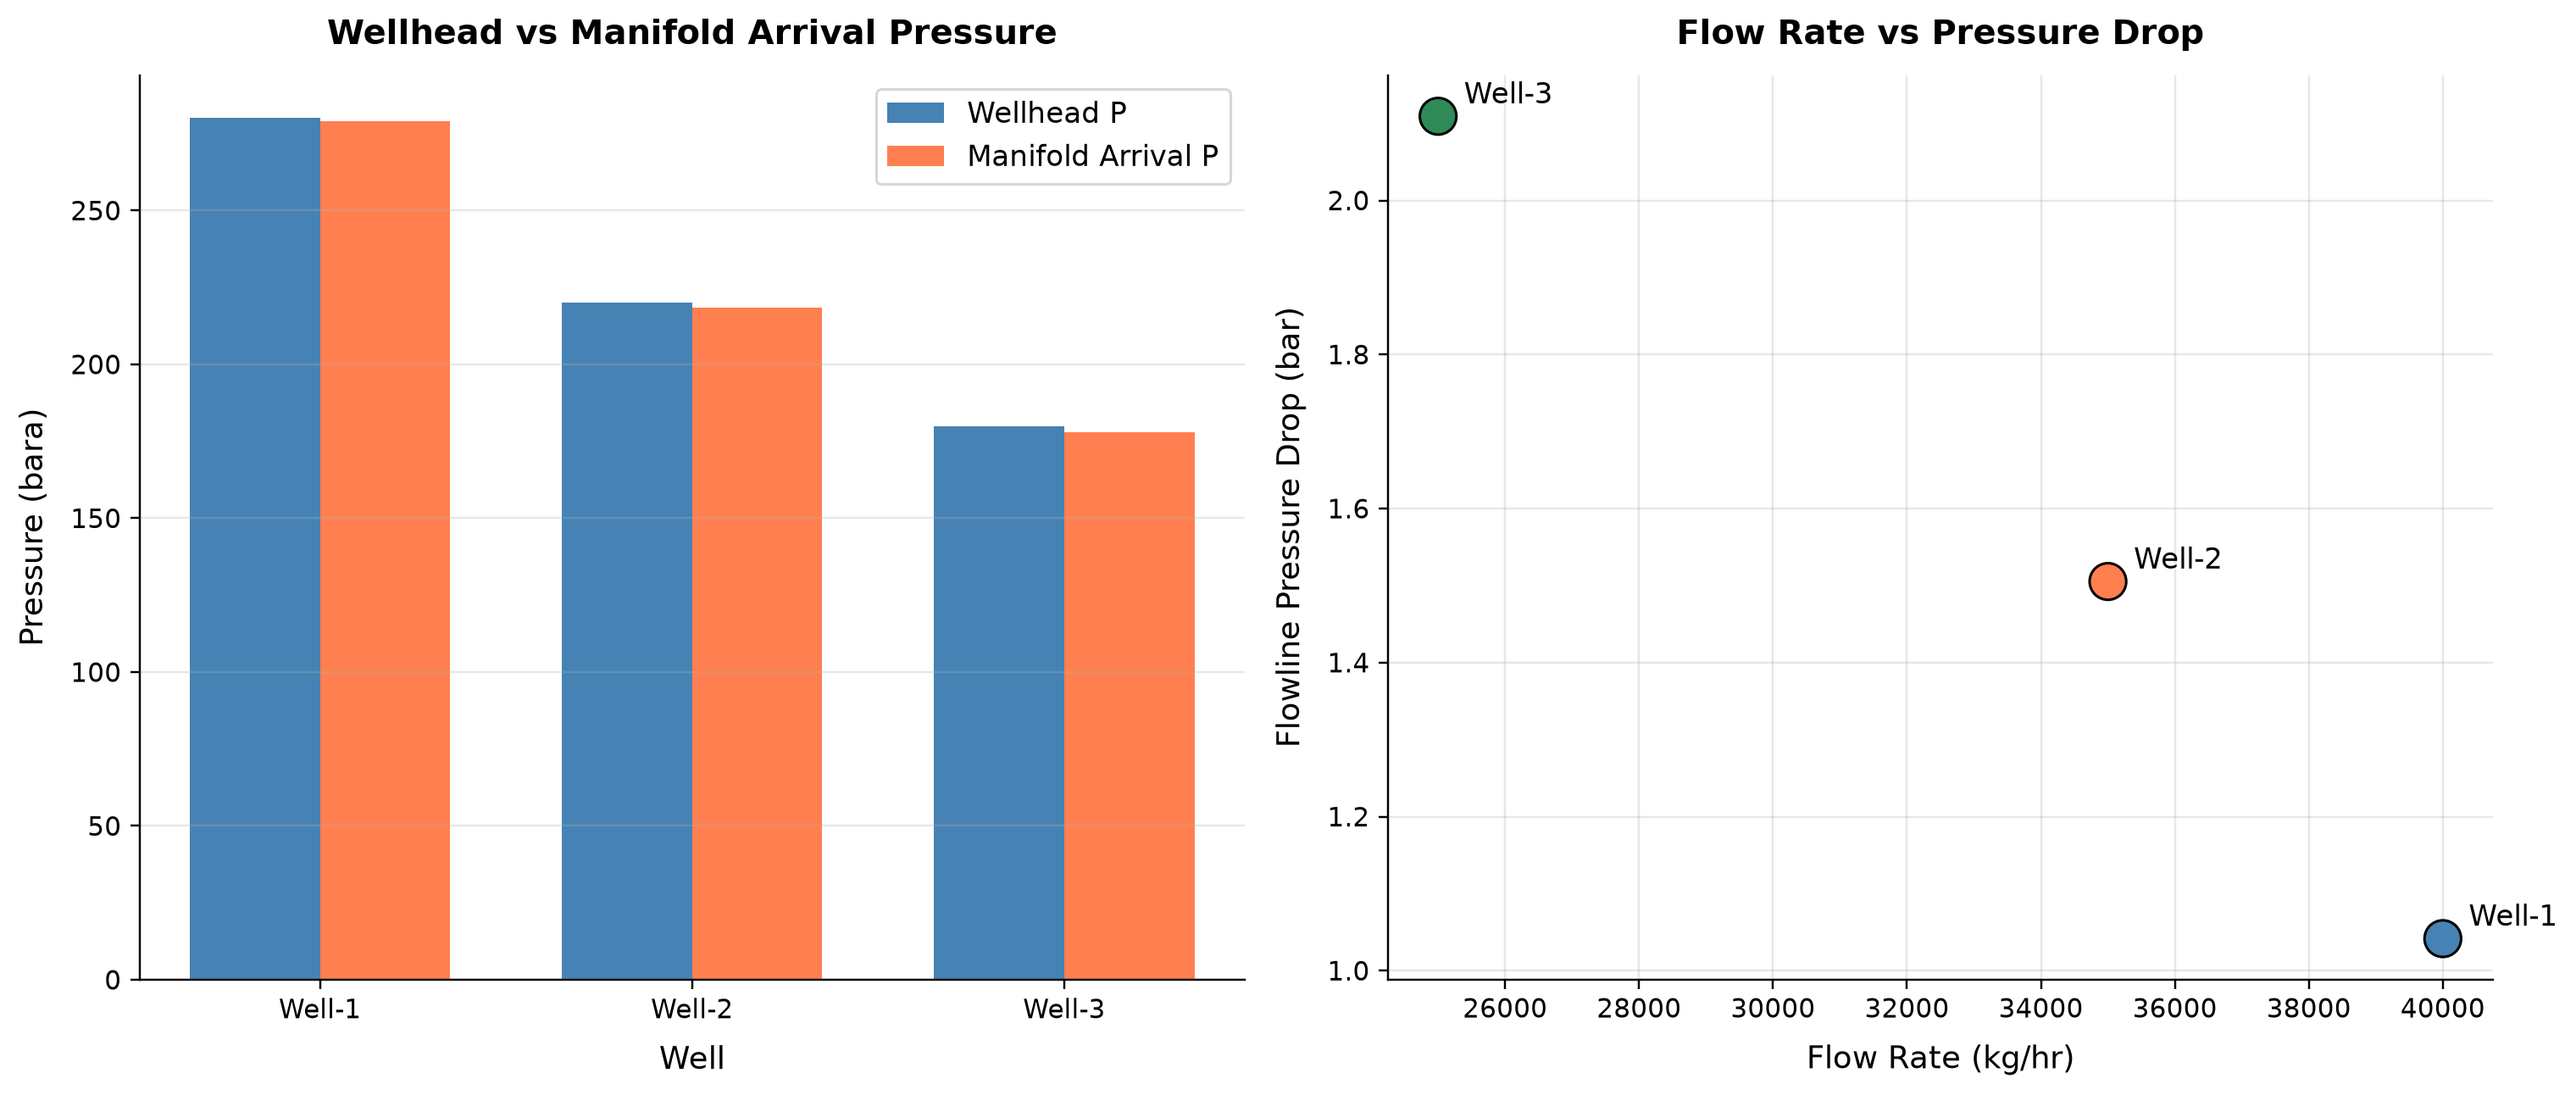

In [6]:
# Plot: Wellhead pressure comparison and pressure drop per well
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

wells = ["Well-1", "Well-2", "Well-3"]
inlet_pressures = [stream1.getPressure("bara"), stream2.getPressure("bara"), stream3.getPressure("bara")]
arrival_pressures = [pipe1.getOutletStream().getPressure("bara"),
                     pipe2.getOutletStream().getPressure("bara"),
                     pipe3.getOutletStream().getPressure("bara")]
pressure_drops = [pipe1.getPressureDrop(), pipe2.getPressureDrop(), pipe3.getPressureDrop()]
flow_rates = [stream1.getFlowRate("kg/hr"), stream2.getFlowRate("kg/hr"), stream3.getFlowRate("kg/hr")]

x = np.arange(len(wells))
width = 0.35

bars1 = ax1.bar(x - width/2, inlet_pressures, width, label="Wellhead P", color="steelblue")
bars2 = ax1.bar(x + width/2, arrival_pressures, width, label="Manifold Arrival P", color="coral")
ax1.set_xlabel("Well", fontsize=12)
ax1.set_ylabel("Pressure (bara)", fontsize=12)
ax1.set_title("Wellhead vs Manifold Arrival Pressure", fontsize=13)
ax1.set_xticks(x)
ax1.set_xticklabels(wells)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

colors = ["steelblue", "coral", "seagreen"]
ax2.scatter(flow_rates, pressure_drops, s=200, c=colors, edgecolors='black', zorder=5)
for i, w in enumerate(wells):
    ax2.annotate(w, (flow_rates[i], pressure_drops[i]), textcoords="offset points",
                 xytext=(10, 5), fontsize=11)
ax2.set_xlabel("Flow Rate (kg/hr)", fontsize=12)
ax2.set_ylabel("Flowline Pressure Drop (bar)", fontsize=12)
ax2.set_title("Flow Rate vs Pressure Drop", fontsize=13)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch15w_well_network_comparison.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved to ../figures/ch15w_well_network_comparison.png")

**Executed-figure discussion.** Wellhead P: pressure spans 180–280 bara across the plotted cases. Manifold Arrival P: pressure spans 177.9–279 bara across the plotted cases.

Each well’s pressure budget depends on its inlet condition and the resistance of its branch to the common manifold. The well with the highest wellhead pressure is not necessarily the largest contributor once branch losses and common backpressure are included. Compare branch residuals and rates on one basis before adjusting chokes or assigning a debottlenecking priority.


## Discussion

**Choke Sensitivity:** As choke opening increases, the pressure drop across the choke
decreases, resulting in higher downstream pressure at the manifold. At low openings
(10-20%), the choke dominates the total system pressure drop. At higher openings,
the frictional losses in the flowline become the dominant contributor.

**Multi-Well Network:** Wells with higher reservoir pressure (Well-1 at 280 bara) deliver
more energy to overcome flowline losses. Well-3, with the longest flowline (6 km) and
lowest wellhead pressure, experiences the greatest proportional pressure loss. The mixer
model equalizes pressures at the manifold, which in practice constrains the lower-pressure
wells.

**Production Optimization Implications:**
- Choke management is essential for rate allocation and back-pressure control
- Wells with longer tiebacks need larger pipe diameters or boosting
- Network balancing requires iterative pressure matching at manifold nodes

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [7]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                           Figure  Panel             Series                    Output / unit  Minimum  Maximum  Finite points  Missing points
      ch15w_choke_sensitivity.png      1     Choke Outlet P     Choke Outlet Pressure (bara)  45.6109  141.552              8               2
      ch15w_choke_sensitivity.png      2         Manifold P Manifold Arrival Pressure (bara)  41.4124  140.254              8               2
ch15w_well_network_comparison.png      1         Wellhead P                  Pressure (bara)      180      280              3               0
ch15w_well_network_comparison.png      1 Manifold Arrival P                  Pressure (bara)  177.891  278.958              3               0
ch15w_well_network_comparison.png      2           Points 1     Flowline Pressure Drop (bar)  1.04157  2.10933              3               0
